In [13]:
# Importation des bibliothèques nécessaires
import cv2
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr
from PIL import Image

# Pour l’évaluation avancée (matrice de confusion, rapport)
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
# Chargement du dataset MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Vérification des dimensions
print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)
print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)


x_train shape : (60000, 28, 28)
y_train shape : (60000,)
x_test shape  : (10000, 28, 28)
y_test shape  : (10000,)


In [4]:
# Normalisation des images (valeurs entre 0 et 1)
x_train = x_train / 255.0
x_test = x_test / 255.0


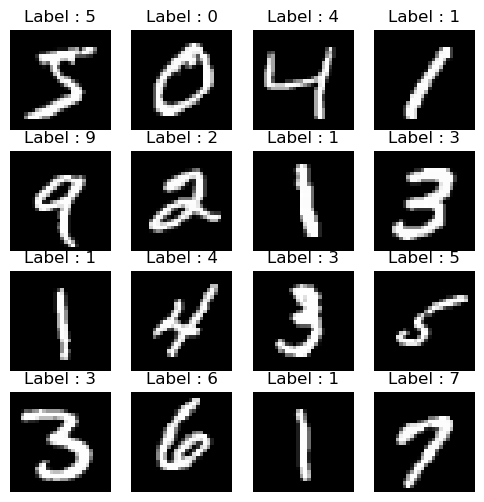

In [5]:
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label : {y_train[i]}")
    plt.axis('off')

plt.show()


In [6]:
# Création du modèle MLP
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement
model.fit(x_train, y_train, epochs=5)

# Sauvegarde
model.save("handwritten_digits.keras")


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9266 - loss: 0.2580
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9669 - loss: 0.1127
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9775 - loss: 0.0776
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9829 - loss: 0.0576
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9865 - loss: 0.0445


In [7]:
# Reshape pour CNN (ajout dimension canal)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Création du modèle CNN
cnn_model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilation
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement avec validation
cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# Évaluation sur test
test_loss, test_accuracy = cnn_model.evaluate(x_test_cnn, y_test)
print("Test accuracy :", test_accuracy)

# Sauvegarde
cnn_model.save("mnist_cnn.keras")


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9548 - loss: 0.1450 - val_accuracy: 0.9862 - val_loss: 0.0458
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9852 - loss: 0.0486 - val_accuracy: 0.9868 - val_loss: 0.0487
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9887 - val_loss: 0.0416
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9929 - loss: 0.0220 - val_accuracy: 0.9892 - val_loss: 0.0376
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 0.9918 - val_loss: 0.0324
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0297
Test accuracy : 0.9904000163078308


In [8]:
# Prédictions
y_pred = cnn_model.predict(x_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)
print("Matrice de confusion :\n", cm)

# Rapport de classification
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Matrice de confusion :
 [[ 977    0    0    0    1    0    0    1    1    0]
 [   0 1129    0    0    0    2    4    0    0    0]
 [   4    0 1021    0    0    0    0    6    1    0]
 [   1    0    1 1002    0    1    0    0    5    0]
 [   0    0    0    0  972    0    4    1    1    4]
 [   2    0    0    7    0  879    1    0    2    1]
 [   7    2    0    0    3    1  943    0    2    0]
 [   0    1    2    1    0    0    0 1022    0    2]
 [   3    0    4    1    0    0    0    0  964    2]
 [   1    1    1    0    5    4    0    0    2  995]]

Classification Report :

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892

In [9]:
# Chargement du modèle sauvegardé
model = tf.keras.models.load_model("mnist_cnn.keras")

# Fonction de prétraitement d'une image externe
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img)
    img = img / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img


In [ ]:
for filename in os.listdir("images"):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        path = os.path.join("images", filename)

        img = preprocess_image(path)
        prediction = model.predict(img)
        probabilities = prediction[0]

        digit = np.argmax(probabilities)

        print(f"\nImage : {filename}")
        print(f"→ Chiffre prédit : {digit}")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(img[0, :, :, 0], cmap="gray")
        plt.title(f"Prédit : {digit}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.bar(range(10), probabilities)
        plt.xticks(range(10))
        plt.xlabel("Chiffres")
        plt.ylabel("Probabilité")
        plt.title("Probabilités softmax")

        plt.show()


In [18]:
model = tf.keras.models.load_model("mnist_cnn.keras")

def predict(data):
    image = data["composite"]

    if isinstance(image, np.ndarray):
        image = image[:, :, 0]

    from PIL import Image
    image = Image.fromarray(image).resize((28, 28))

    image = np.array(image) / 255.0
    image = 1 - image  # invert for MNIST

    image = image.reshape(1, 28, 28)

    prediction = model.predict(image)
    return int(np.argmax(prediction))


demo = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(width=280, height=280),
    outputs="label"
)

demo.launch(inline=True)


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
